# Phase 5c: Tree-Based Ensembles

This notebook estimates random forest and gradient boosting prediction models using the Phase 5a modeling dataset and the same time-aware splits used in Phase 5b.

## Setup

In [1]:
from pathlib import Path
from itertools import product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'modeling_dataset_5a_with_splits.csv'
FEATURE_PATH = PROJECT_ROOT / 'outputs' / 'model_feature_set_5a.md'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
feature_lines = FEATURE_PATH.read_text(encoding='utf-8').splitlines()
features = [line.strip()[3:-1] for line in feature_lines if line.strip().startswith('- `') and line.strip().endswith('`')]

outcome = 'unmet_need_pc'
missing_features = [feature for feature in features if feature not in df.columns]
if missing_features:
    raise ValueError(f'Missing features in modeling dataset: {missing_features}')

X_train = df.loc[df['split'] == 'train', features]
y_train = df.loc[df['split'] == 'train', outcome]
X_valid = df.loc[df['split'] == 'valid', features]
y_valid = df.loc[df['split'] == 'valid', outcome]
X_test = df.loc[df['split'] == 'test', features]
y_test = df.loc[df['split'] == 'test', outcome]

X_train_valid = pd.concat([X_train, X_valid], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'rows': [len(X_train), len(X_valid), len(X_test)],
    'min_year': [df.loc[df['split'] == split, 'year'].min() for split in ['train', 'valid', 'test']],
    'max_year': [df.loc[df['split'] == split, 'year'].max() for split in ['train', 'valid', 'test']],
})

,split,rows,min_year,max_year
0,train,102,2015,2018
1,valid,52,2019,2020
2,test,76,2021,2023


In [2]:
def evaluate_predictions(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }


def tune_model(model_name, model_class, param_grid):
    rows = []
    param_names = list(param_grid.keys())
    for values in product(*param_grid.values()):
        params = dict(zip(param_names, values))
        model = model_class(**params)
        model.fit(X_train, y_train)
        valid_pred = model.predict(X_valid)
        valid_metrics = evaluate_predictions(y_valid, valid_pred)
        rows.append({
            'model_name': model_name,
            **params,
            'mae_valid': valid_metrics['mae'],
            'rmse_valid': valid_metrics['rmse'],
            'r2_valid': valid_metrics['r2'],
        })
    tuning = pd.DataFrame(rows).sort_values(['rmse_valid', 'mae_valid']).reset_index(drop=True)
    best_params = {}
    for name in param_names:
        value = tuning.loc[0, name]
        if pd.isna(value) and any(option is None for option in param_grid[name]):
            value = None
        elif isinstance(value, np.integer):
            value = int(value)
        elif isinstance(value, np.floating):
            value = float(value)
            if value.is_integer() and all((option is None or isinstance(option, int)) for option in param_grid[name]):
                value = int(value)
        best_params[name] = value
    final_model = model_class(**best_params)
    final_model.fit(X_train_valid, y_train_valid)
    test_pred = final_model.predict(X_test)
    test_metrics = evaluate_predictions(y_test, test_pred)
    return tuning, best_params, final_model, test_metrics

## Random Forest and Gradient Boosting

In [3]:
rf_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 3],
    'random_state': [RANDOM_STATE],
}

gb_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'random_state': [RANDOM_STATE],
}

rf_tuning, rf_best_params, rf_model, rf_test_metrics = tune_model('Random Forest', RandomForestRegressor, rf_grid)
gb_tuning, gb_best_params, gb_model, gb_test_metrics = tune_model('Gradient Boosting', GradientBoostingRegressor, gb_grid)

rf_tuning.to_csv(OUTPUTS_DIR / 'random_forest_validation_tuning.csv', index=False)
gb_tuning.to_csv(OUTPUTS_DIR / 'gradient_boosting_validation_tuning.csv', index=False)

rf_best_params, gb_best_params

({'n_estimators': 300,
  'max_depth': None,
  'min_samples_leaf': 1,
  'random_state': 42},
 {'n_estimators': 100,
  'learning_rate': 0.1,
  'max_depth': 2,
  'random_state': 42})

In [4]:
performance = pd.DataFrame([
    {
        'model_name': 'Random Forest',
        'n_estimators': rf_best_params.get('n_estimators'),
        'max_depth': rf_best_params.get('max_depth'),
        'learning_rate': np.nan,
        'mae_test': rf_test_metrics['mae'],
        'rmse_test': rf_test_metrics['rmse'],
        'r2_test': rf_test_metrics['r2'],
    },
    {
        'model_name': 'Gradient Boosting',
        'n_estimators': gb_best_params.get('n_estimators'),
        'max_depth': gb_best_params.get('max_depth'),
        'learning_rate': gb_best_params.get('learning_rate'),
        'mae_test': gb_test_metrics['mae'],
        'rmse_test': gb_test_metrics['rmse'],
        'r2_test': gb_test_metrics['r2'],
    },
])
performance.to_csv(OUTPUTS_DIR / 'table_tree_models_performance.csv', index=False)
performance

,model_name,n_estimators,max_depth,learning_rate,mae_test,rmse_test,r2_test
0,Random Forest,300,NaN,NaN,1.051162,1.571729,0.573601
1,Gradient Boosting,100,2.0,0.1,1.130114,1.525845,0.598134


## Feature Importance and Partial Dependence

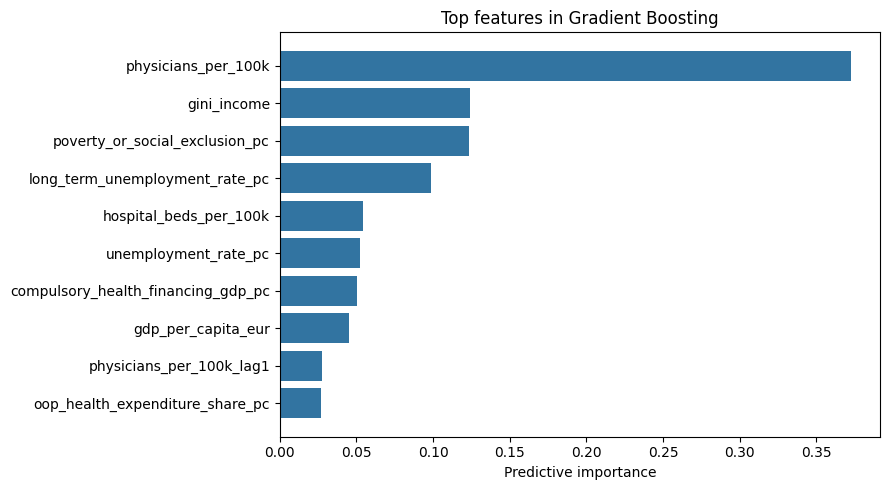

,feature,importance
0,physicians_per_100k,0.372777
1,gini_income,0.123894
2,poverty_or_social_exclusion_pc,0.123178
3,long_term_unemployment_rate_pc,0.098794
4,hospital_beds_per_100k,0.054339
5,unemployment_rate_pc,0.052671
6,compulsory_health_financing_gdp_pc,0.050278
7,gdp_per_capita_eur,0.045389
8,physicians_per_100k_lag1,0.027401
9,oop_health_expenditure_share_pc,0.026955


In [5]:
best_tree_row = performance.sort_values(['rmse_test', 'mae_test']).iloc[0]
best_tree_model = rf_model if best_tree_row['model_name'] == 'Random Forest' else gb_model

importance = pd.DataFrame({
    'feature': features,
    'importance': best_tree_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
importance.to_csv(OUTPUTS_DIR / 'tree_feature_importance.csv', index=False)

plt.figure(figsize=(9, 5))
top_importance = importance.head(10).sort_values('importance', ascending=True)
plt.barh(top_importance['feature'], top_importance['importance'], color='#3274a1')
plt.xlabel('Predictive importance')
plt.title(f"Top features in {best_tree_row['model_name']}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tree_feature_importance.png', dpi=200)
plt.show()

importance.head(10)

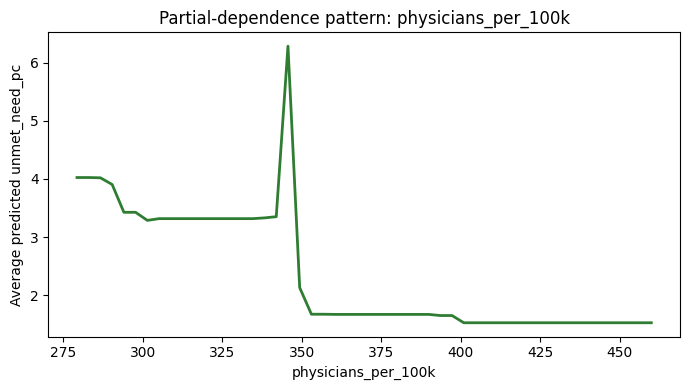

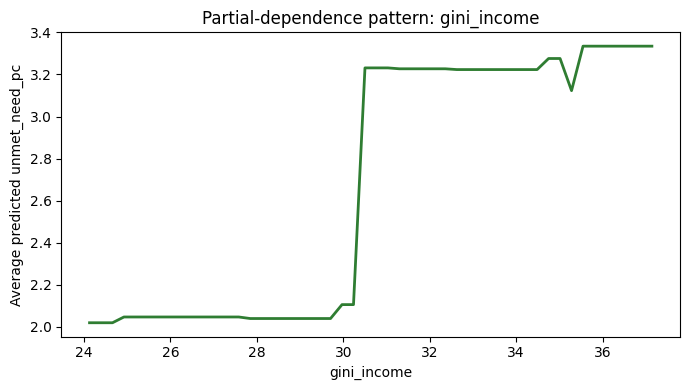

['physicians_per_100k', 'gini_income']

In [6]:
def plot_simple_partial_dependence(model, data, feature, output_path):
    grid = np.linspace(data[feature].quantile(0.05), data[feature].quantile(0.95), 50)
    averages = []
    for value in grid:
        temp = data.copy()
        temp[feature] = value
        averages.append(model.predict(temp).mean())
    plt.figure(figsize=(7, 4))
    plt.plot(grid, averages, color='#2f7d32', linewidth=2)
    plt.xlabel(feature)
    plt.ylabel('Average predicted unmet_need_pc')
    plt.title(f'Partial-dependence pattern: {feature}')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()
    return pd.DataFrame({feature: grid, 'average_prediction': averages})

pdp_features = importance['feature'].head(2).tolist()
pdp_tables = {}
for feature in pdp_features:
    output_path = FIGURES_DIR / f'tree_pdp_{feature}.png'
    pdp_tables[feature] = plot_simple_partial_dependence(best_tree_model, X_train_valid, feature, output_path)

pdp_features

## Performance Summary

In [7]:
linear_performance = pd.read_csv(OUTPUTS_DIR / 'table_linear_models_performance.csv')
best_linear = linear_performance.sort_values(['rmse_test', 'mae_test']).iloc[0]
best_tree = performance.sort_values(['rmse_test', 'mae_test']).iloc[0]
top_features = importance.head(5)['feature'].tolist()

if best_tree['rmse_test'] < best_linear['rmse_test']:
    comparison_sentence = (
        f"The best tree model, {best_tree['model_name']}, has lower test RMSE than the best linear model, "
        f"{best_linear['model_name']}. The RMSE difference is {best_linear['rmse_test'] - best_tree['rmse_test']:.3f} points, "
        f"and the MAE difference is {best_linear['mae_test'] - best_tree['mae_test']:.3f} points."
    )
else:
    comparison_sentence = (
        f"The best tree model, {best_tree['model_name']}, does not improve test RMSE relative to the best linear model, "
        f"{best_linear['model_name']}. The tree RMSE is {best_tree['rmse_test']:.3f}, compared with "
        f"{best_linear['rmse_test']:.3f} for the linear benchmark."
    )

summary_lines = [
    '# Tree models summary',
    '',
    (
        f"The best tree-based test result is from {best_tree['model_name']}, with MAE {best_tree['mae_test']:.3f}, "
        f"RMSE {best_tree['rmse_test']:.3f}, and R-squared {best_tree['r2_test']:.3f}."
    ),
    '',
    comparison_sentence,
    '',
    'The highest predictive-importance features in the selected tree model are: ' + ', '.join(f'`{feature}`' for feature in top_features) + '.',
    '',
    'These importance values describe prediction patterns in the fitted model. They are not causal evidence and should not be read as policy evaluation.',
    '',
]
summary = '\n'.join(summary_lines)
(OUTPUTS_DIR / 'tree_models_summary.md').write_text(summary, encoding='utf-8')
print(summary)

# Tree models summary

The best tree-based test result is from Gradient Boosting, with MAE 1.130, RMSE 1.526, and R-squared 0.598.

The best tree model, Gradient Boosting, has lower test RMSE than the best linear model, Lasso. The RMSE difference is 0.361 points, and the MAE difference is 0.298 points.

The highest predictive-importance features in the selected tree model are: `physicians_per_100k`, `gini_income`, `poverty_or_social_exclusion_pc`, `long_term_unemployment_rate_pc`, `hospital_beds_per_100k`.

These importance values describe prediction patterns in the fitted model. They are not causal evidence and should not be read as policy evaluation.

